# Planning Plots

In [1]:
# Libraries
import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt
import json
from simulation.trajectory_sampler import *
from envs import *
from policies import *
from data_processors import *
from scipy.stats import sem, t
import os


# font = {'size'   : 20}
# plt.rc('font', **font)  # pass in the font dict as kwargs



# SWIMMER

In [179]:
# Path principali per i risultati
paths = ["/Users/gianmarcotedeschi/Projects/learnRL/results/_12_09-17_25_CLOL_Planning_500_swimmer_1000_1_constant_0001_100_noclip__deep_gaussian_416_std_1",
         "/Users/gianmarcotedeschi/Projects/learnRL/results/_12_10-14_54_CLOL_Planning_500_swimmer_1000_3_constant_0001_100_noclip__deep_gaussian_480_std_1",
         "/Users/gianmarcotedeschi/Projects/learnRL/results/_12_10-18_48_CLOL_Planning_500_swimmer_1000_10_constant_0001_100_noclip__deep_gaussian_704_std_1",
         "/Users/gianmarcotedeschi/Projects/learnRL/results/_12_10-21_54_CLOL_Planning_500_swimmer_1000_20_constant_0001_100_noclip__deep_gaussian_1024_std_1"]


# Etichette per i set di risultati
labels = [
    "L=1",
    "L=3",
    "L=10",
    "L=20"
]

# Funzione per caricare i dati da un percorso
def load_trials(base_path):
    trial_performances = []
    for i in range(2):  # Supponiamo un massimo di 50 trial (modificabile)
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "pg_results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_performances.append(data["performance"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_performances)  # Converte in array per calcoli successivi

# Lista per memorizzare le performance per ogni set
all_performances = []
for path in paths:
    performances = load_trials(path)
    if performances.size > 0:
        all_performances.append(performances)



<Figure size 640x480 with 0 Axes>

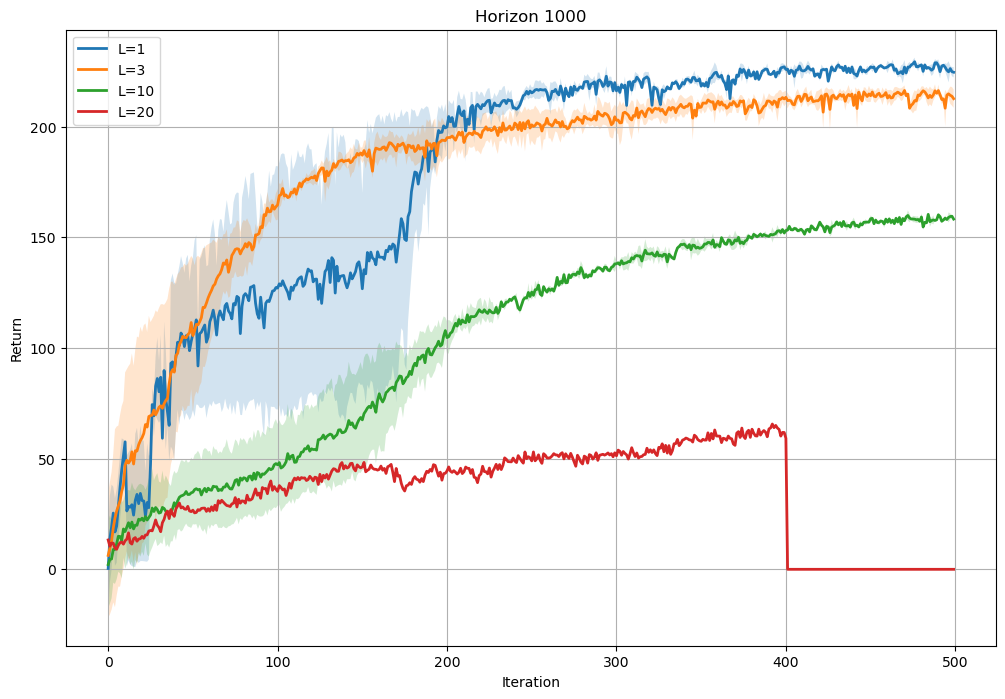

In [180]:
# Plot dei grafici
plt.clf()
plt.figure(figsize=(12, 8))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
        # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        conf_interval_lower = np.percentile(performances, 2.5, axis=0)
        conf_interval_upper = np.percentile(performances, 97.5, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, label=f"{labels[i]}", linewidth=2)

        # Plot dell'intervallo di confidenza
        plt.fill_between(
            range(len(mean_performance)),
            conf_interval_lower,
            conf_interval_upper,
            alpha=0.2
        )

# Etichette e titolo
plt.title("Horizon 1000")
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.legend(loc="best")
plt.grid()

# Salva e mostra il grafico
# plt.savefig("swimmer_h500_nn_416.pdf", format='pdf')
plt.show()

In [ ]:
# Path to results_debug
base_path = ["/Users/gianmarcotedeschi/Projects/learnRL/results/_12_02-19_17_CLOL_Planning_500_swimmer_100_1_constant_0001_lin_gaussian_batch_100_clip_16_std_1",
             "/Users/gianmarcotedeschi/Projects/learnRL/results/_12_02-19_46_CLOL_Planning_500_swimmer_100_3_constant_0001_lin_gaussian_batch_100_clip_48_std_1",
             "/Users/gianmarcotedeschi/Projects/learnRL/results/_12_02-20_09_CLOL_Planning_500_swimmer_100_10_constant_0001_lin_gaussian_batch_100_clip_160_std_1"]

# Labels per i trial
lab = [
    "L=20",
    "L=200",
    "L=1"
]

# Lista dei dati
data = []

# Esplora le cartelle trial_x nel path
for p in base_path:
    for i in range(5):  # Supponiamo di avere fino a 10 trial (puoi aumentare questo numero)
        trial_path = os.path.join(p, f"trial_{i}")
        
        # Verifica se la cartella esiste
        if os.path.isdir(trial_path):
            try:
                # Carica i dati dal file JSON
                name = os.path.join(trial_path, "pg_results.json")
                with open(name, 'r') as file:
                    data.append(json.load(file))
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nell'aprire il file {name}: {e}")

# Calcolare gli intervalli di confidenza (95%) per la performance media
performances = []
for trial_data in data:
    performances.append(trial_data["performance"])

# Trasforma la lista in un array numpy per facilitare i calcoli
performances = np.array(performances)

# Calcola la media e l'intervallo di confidenza (percentili 2.5 e 97.5)
mean_performance = np.mean(performances, axis=0)
conf_interval_lower = np.percentile(performances, 2.5, axis=0)
conf_interval_upper = np.percentile(performances, 97.5, axis=0)

# Plot della curva di apprendimento con intervallo di confidenza
plt.clf()
# plt.figure(figsize=(10, 8))

# Traccia la performance media
plt.plot(mean_performance, label="1", color="b")

# Traccia l'intervallo di confidenza al 95%
plt.fill_between(range(len(mean_performance)), conf_interval_lower, conf_interval_upper, color="blue", alpha=0.2)

# Etichette e titolo
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.legend(loc="best")
plt.grid()

# Salva e mostra il grafico
plt.savefig("h_100_nn_416.pdf", format='pdf')
plt.show()


<Figure size 640x480 with 0 Axes>

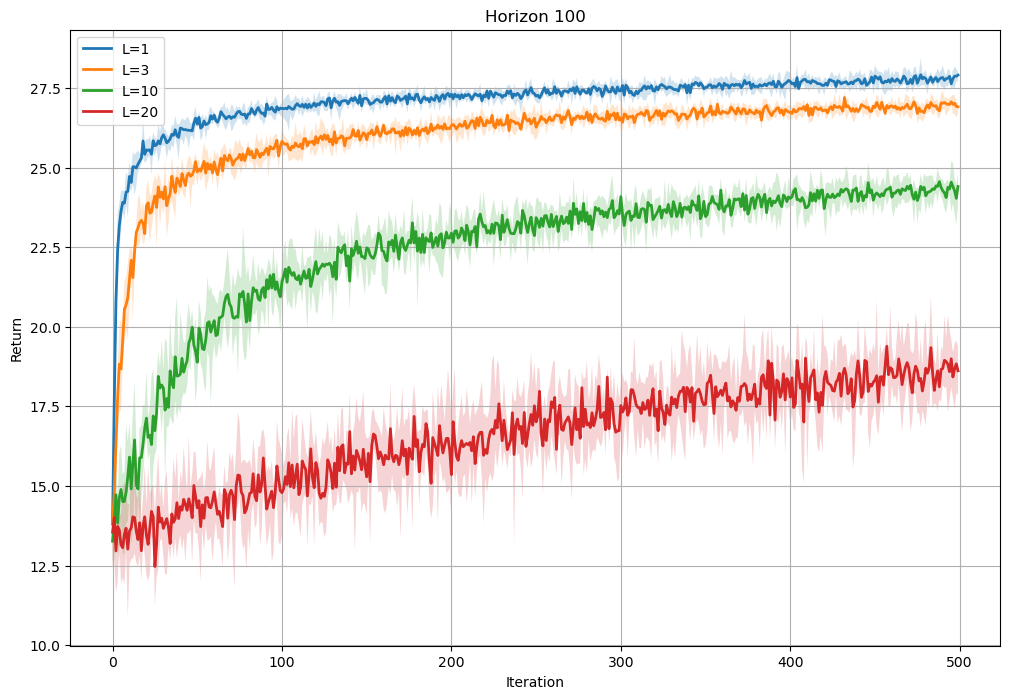

In [89]:
# Path principali per i risultati
paths = ["/Users/gianmarcotedeschi/Projects/learnRL/results/_12_02-19_17_CLOL_Planning_500_swimmer_100_1_constant_0001_lin_gaussian_batch_100_clip_16_std_1",
             "/Users/gianmarcotedeschi/Projects/learnRL/results/_12_02-19_46_CLOL_Planning_500_swimmer_100_3_constant_0001_lin_gaussian_batch_100_clip_48_std_1",
             "/Users/gianmarcotedeschi/Projects/learnRL/results/_12_02-20_09_CLOL_Planning_500_swimmer_100_10_constant_0001_lin_gaussian_batch_100_clip_160_std_1",
             "/Users/gianmarcotedeschi/Projects/learnRL/results/_12_02-20_30_CLOL_Planning_500_swimmer_100_20_constant_0001_lin_gaussian_batch_100_clip_320_std_1"]


# Etichette per i set di risultati
labels = [
    "L=1",
    "L=3",
    "L=10",
    "L=20"
]

# Funzione per caricare i dati da un percorso
def load_trials(base_path):
    trial_performances = []
    for i in range(50):  # Supponiamo un massimo di 50 trial (modificabile)
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "pg_results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_performances.append(data["performance"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_performances)  # Converte in array per calcoli successivi

# Lista per memorizzare le performance per ogni set
all_performances = []
for path in paths:
    performances = load_trials(path)
    if performances.size > 0:
        all_performances.append(performances)

# Plot dei grafici
plt.clf()
plt.figure(figsize=(12, 8))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
        # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        conf_interval_lower = np.percentile(performances, 2.5, axis=0)
        conf_interval_upper = np.percentile(performances, 97.5, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, label=f"{labels[i]}", linewidth=2)

        # Plot dell'intervallo di confidenza
        plt.fill_between(
            range(len(mean_performance)),
            conf_interval_lower,
            conf_interval_upper,
            alpha=0.2
        )

# Etichette e titolo
plt.title("Horizon 100")
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.legend(loc="best")
plt.grid()

# Salva e mostra il grafico
plt.savefig("swimmer_h100.pdf", format='pdf')
plt.show()


In [ ]:
# Path principali per i risultati
paths = ["/Users/gianmarcotedeschi/Projects/learnRL/results/_12_02-21_28_CLOL_Planning_500_swimmer_500_1_constant_0001_lin_gaussian_batch_100_clip_16_std_1",
             "/Users/gianmarcotedeschi/Projects/learnRL/results/_12_02-23_59_CLOL_Planning_500_swimmer_500_3_constant_0001_lin_gaussian_batch_100_clip_48_std_1",
             "/Users/gianmarcotedeschi/Projects/learnRL/results/_12_03-01_49_CLOL_Planning_500_swimmer_500_10_constant_0001_lin_gaussian_batch_100_clip_160_std_1",
             "/Users/gianmarcotedeschi/Projects/learnRL/results/_12_03-03_35_CLOL_Planning_500_swimmer_500_20_constant_0001_lin_gaussian_batch_100_clip_320_std_1"]


# Etichette per i set di risultati
labels = [
    "L=1",
    "L=3",
    "L=10",
    "L=20"
]

# Funzione per caricare i dati da un percorso
def load_trials(base_path):
    trial_performances = []
    for i in range(50):  # Supponiamo un massimo di 50 trial (modificabile)
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "pg_results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_performances.append(data["performance"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_performances)  # Converte in array per calcoli successivi

# Lista per memorizzare le performance per ogni set
all_performances = []
for path in paths:
    performances = load_trials(path)
    if performances.size > 0:
        all_performances.append(performances)

# Plot dei grafici
plt.clf()
plt.figure(figsize=(12, 8))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
        # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        conf_interval_lower = np.percentile(performances, 2.5, axis=0)
        conf_interval_upper = np.percentile(performances, 97.5, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, label=f"{labels[i]}", linewidth=2)

        # Plot dell'intervallo di confidenza
        plt.fill_between(
            range(len(mean_performance)),
            conf_interval_lower,
            conf_interval_upper,
            alpha=0.2
        )

# Etichette e titolo
plt.title("Horizon 500")
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.legend(loc="best")
plt.grid()

# Salva e mostra il grafico
plt.savefig("swimmer_h500.pdf", format='pdf')
plt.show()


In [ ]:
# Path principali per i risultati
paths = ["/Users/gianmarcotedeschi/Projects/learnRL/results/_12_03-05_22_CLOL_Planning_500_swimmer_1000_1_constant_0001_lin_gaussian_batch_100_clip_16_std_1",
             "/Users/gianmarcotedeschi/Projects/learnRL/results/_12_03-09_52_CLOL_Planning_500_swimmer_1000_3_constant_0001_lin_gaussian_batch_100_clip_48_std_1",
             "/Users/gianmarcotedeschi/Projects/learnRL/results/_12_03-14_57_CLOL_Planning_500_swimmer_1000_10_constant_0001_lin_gaussian_batch_100_clip_160_std_1"]


# Etichette per i set di risultati
labels = [
    "L=1",
    "L=3",
    "L=10",
    "L=20"
]

# Funzione per caricare i dati da un percorso
def load_trials(base_path):
    trial_performances = []
    for i in range(50):  # Supponiamo un massimo di 50 trial (modificabile)
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "pg_results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_performances.append(data["performance"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_performances)  # Converte in array per calcoli successivi

# Lista per memorizzare le performance per ogni set
all_performances = []
for path in paths:
    performances = load_trials(path)
    if performances.size > 0:
        all_performances.append(performances)

# Plot dei grafici
plt.clf()
plt.figure(figsize=(12, 8))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
        # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        conf_interval_lower = np.percentile(performances, 2.5, axis=0)
        conf_interval_upper = np.percentile(performances, 97.5, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, label=f"{labels[i]}", linewidth=2)

        # Plot dell'intervallo di confidenza
        plt.fill_between(
            range(len(mean_performance)),
            conf_interval_lower,
            conf_interval_upper,
            alpha=0.2
        )

# Etichette e titolo
plt.title("Horizon 1000")
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.legend(loc="best")
plt.grid()

# Salva e mostra il grafico
# plt.savefig("swimmer_h1000.pdf", format='pdf')
plt.show()
